# Stokes Flow with Taylor-Hood Mixed Elements

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/camlab-ethz/TensorMesh/blob/main/notebooks/stokes_taylor_hood.ipynb)

A manufactured incompressible Stokes problem on the unit square, solved with
the LBB-stable **P2-P1 Taylor-Hood pair** via TensorMesh's
`MixedElementAssembler` — declare the fields, write the weak form, and the
mixed saddle-point system is assembled for you. A small h-refinement study
verifies the expected convergence rates.

Docs: [docs.tensor-mesh.com](https://docs.tensor-mesh.com) · Source: [github.com/camlab-ethz/TensorMesh](https://github.com/camlab-ethz/TensorMesh)

In [1]:
# Install TensorMesh (skipped automatically if it is already available, e.g. a local dev setup).
# The apt line provides the OpenGL utility library that gmsh -- TensorMesh's mesh generator --
# needs at import time; it is a no-op where the library is already present.
import importlib.util
if importlib.util.find_spec("tensormesh") is None:
    !apt-get -qq install -y libglu1-mesa > /dev/null 2>&1 || true
    %pip install -q tensormesh-fem==0.2.0

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from tensormesh import Condenser, Field, Mesh, MixedElementAssembler, NodeAssembler

MU = 1.0
QUADRATURE_ORDER = 7

## Weak form

$$\mu\,\nabla u : \nabla v - p\,\nabla\cdot v - q\,\nabla\cdot u$$

Each `Field` declares a trial/test pair with its polynomial order and number
of components; `forward` receives them by name. The body force is assembled
separately with a `NodeAssembler`.

In [3]:
class StokesAssembler(MixedElementAssembler):
    r"""Taylor-Hood Stokes bilinear form.

    .. math::

        \mu\,\nabla u : \nabla v - p\,\nabla\cdot v - q\,\nabla\cdot u.

    Trial fields ``(u, p)`` index columns and test fields ``(v, q)`` index
    rows. The P2 velocity field carries two components; the P1 pressure field
    lives only on the corner vertices of the same P2 mesh.
    """

    fields = [
        Field(trial="u", test="v", order=2, components=2),
        Field(trial="p", test="q", order=1),
    ]

    def __post_init__(self, mu=1.0):
        self.mu = mu

    def forward(self, gradu, p, gradv, q):
        div_u = gradu.diagonal().sum()
        div_v = gradv.diagonal().sum()
        return self.mu * (gradu * gradv).sum() - p * div_v - q * div_u


class BodyForceAssembler(NodeAssembler):
    """Assemble the velocity load ``int_Omega f . v dx``."""

    def __post_init__(self, mu=1.0):
        self.mu = mu

    def forward(self, v, x):
        return exact_body_force(x, self.mu) * v

## Manufactured solution

Velocity from the stream function $\psi = \sin^2(\pi x)\,\sin^2(\pi y)$
(divergence-free by construction, zero on the boundary) and pressure
$p = \sin(\pi x)\cos(\pi y)$; the body force follows from
$-\mu \Delta u + \nabla p = f$.

In [4]:
def exact_velocity(points):
    """Divergence-free velocity from ``psi = sin(pi x)^2 sin(pi y)^2``."""
    pi = math.pi
    x, y = points[..., 0], points[..., 1]
    ux = pi * torch.sin(pi * x) ** 2 * torch.sin(2.0 * pi * y)
    uy = -pi * torch.sin(2.0 * pi * x) * torch.sin(pi * y) ** 2
    return torch.stack([ux, uy], dim=-1)


def exact_velocity_gradient(points):
    """Gradient of :func:`exact_velocity`, shape ``[..., component, dim]``."""
    pi = math.pi
    x, y = points[..., 0], points[..., 1]

    dux_dx = pi**2 * torch.sin(2.0 * pi * x) * torch.sin(2.0 * pi * y)
    dux_dy = 2.0 * pi**2 * torch.sin(pi * x) ** 2 * torch.cos(2.0 * pi * y)
    duy_dx = -2.0 * pi**2 * torch.cos(2.0 * pi * x) * torch.sin(pi * y) ** 2
    duy_dy = -pi**2 * torch.sin(2.0 * pi * x) * torch.sin(2.0 * pi * y)

    return torch.stack(
        [
            torch.stack([dux_dx, dux_dy], dim=-1),
            torch.stack([duy_dx, duy_dy], dim=-1),
        ],
        dim=-2,
    )


def exact_velocity_laplacian(points):
    """Component-wise Laplacian of :func:`exact_velocity`."""
    pi = math.pi
    x, y = points[..., 0], points[..., 1]

    lap_ux = (
        2.0 * pi**3 * torch.cos(2.0 * pi * x) * torch.sin(2.0 * pi * y)
        - 4.0 * pi**3 * torch.sin(pi * x) ** 2 * torch.sin(2.0 * pi * y)
    )
    lap_uy = (
        4.0 * pi**3 * torch.sin(2.0 * pi * x) * torch.sin(pi * y) ** 2
        - 2.0 * pi**3 * torch.sin(2.0 * pi * x) * torch.cos(2.0 * pi * y)
    )
    return torch.stack([lap_ux, lap_uy], dim=-1)


def exact_pressure(points):
    """Zero-mean pressure, not contained in the P1 pressure space."""
    pi = math.pi
    x, y = points[..., 0], points[..., 1]
    return torch.sin(pi * x) * torch.cos(pi * y)


def exact_pressure_gradient(points):
    """Gradient of :func:`exact_pressure`."""
    pi = math.pi
    x, y = points[..., 0], points[..., 1]
    return torch.stack(
        [
            pi * torch.cos(pi * x) * torch.cos(pi * y),
            -pi * torch.sin(pi * x) * torch.sin(pi * y),
        ],
        dim=-1,
    )


def exact_body_force(points, mu):
    r"""Forcing for ``-mu Delta u + grad p = f``."""
    return -mu * exact_velocity_laplacian(points) + exact_pressure_gradient(points)

In [5]:
def compute_error_norms(assembler, velocity, pressure):
    """Quadrature-based velocity H1 error and pressure L2 error."""
    h1_u_sq = velocity.new_tensor(0.0)
    l2_p_sq = velocity.new_tensor(0.0)

    for element_type in assembler.element_types:
        trans = assembler.transformation[element_type]
        elements = assembler.elements[element_type]

        shape_val = trans.batch_shape_val(0, trans.n_quadrature)
        shape_grad, jxw = trans.batch_shape_grad_jxw(
            quadrature_start=0,
            quadrature_batch=trans.n_quadrature,
        )

        x_q = torch.einsum("ebd,qb->eqd", trans.element_coords, shape_val)
        u_e = velocity[elements]
        u_h = torch.einsum("ebc,qb->eqc", u_e, shape_val)
        grad_u_h = torch.einsum("ebc,eqbd->eqcd", u_e, shape_grad)

        u_err_sq = (u_h - exact_velocity(x_q)).square().sum(dim=-1)
        grad_u_err_sq = (
            grad_u_h - exact_velocity_gradient(x_q)
        ).square().sum(dim=(-2, -1))
        h1_u_sq = h1_u_sq + ((u_err_sq + grad_u_err_sq) * jxw).sum()

        p_conn = assembler.field_conn[f"p__{element_type}"]
        p_shape_val = assembler.ref_val[f"p__{element_type}"]
        p_h = torch.einsum("eb,qb->eq", pressure[p_conn], p_shape_val)
        l2_p_sq = l2_p_sq + ((p_h - exact_pressure(x_q)).square() * jxw).sum()

    return math.sqrt(h1_u_sq.item()), math.sqrt(l2_p_sq.item())

## Solve

Boundary conditions: exact velocity on all boundary DOFs, plus one pinned
pressure node to fix the gauge. The `layout` helpers map between fields and
the mixed DOF vector.

In [6]:
def solve_stokes(mu=MU, h=0.05, quadrature_order=QUADRATURE_ORDER, verbose=True):
    """Solve one manufactured Stokes problem and return fields plus errors."""
    # 1. Mesh and mixed Taylor-Hood layout.
    mesh = Mesh.gen_rectangle(chara_length=h, order=2, element_type="tri").double()
    assembler = StokesAssembler.from_mesh(mesh, quadrature_order=quadrature_order, mu=mu)
    layout = assembler.layout
    if verbose:
        print(
            f"h={h:.4f}: {mesh.points.shape[0]} P2 velocity nodes, "
            f"{layout.n_nodes('p')} P1 pressure nodes, {layout.n_dofs} DOFs"
        )

    # 2. Dirichlet data: exact velocity on the boundary, one pressure pin.
    bc_mask = layout.dof_mask("u", mesh.boundary_mask)
    pressure_pin = layout.dof_index("p", int(layout.node_ids("p")[0]))
    bc_mask[pressure_pin] = True

    bc_val = torch.zeros(layout.n_dofs, dtype=torch.float64)
    bc_val[layout.dof_mask("u")] = exact_velocity(mesh.points).reshape(-1)
    bc_val[pressure_pin] = exact_pressure(layout.points("p"))[0]

    condenser = Condenser(bc_mask, bc_val[bc_mask])

    # 3. Assemble and solve the saddle-point system.
    K = assembler()
    body_rhs = BodyForceAssembler.from_mesh(
        mesh, quadrature_order=quadrature_order, mu=mu,
    )(batch_size=-1)

    f = layout.cat(u=body_rhs, p=0.0)
    K_inner, f_inner = condenser(K, f)
    sol = condenser.recover(K_inner.solve(f_inner))

    # 4. Split the mixed vector and compute verification errors.
    fields = layout.split(sol)
    h1_u, l2_p = compute_error_norms(assembler, fields["u"], fields["p"])
    if verbose:
        print(f"  ||u_h - u||_H1 = {h1_u:.6e}   ||p_h - p||_L2 = {l2_p:.6e}")

    return {"h": h, "h1_u": h1_u, "l2_p": l2_p,
            "mesh": mesh, "layout": layout, "fields": fields}


h=0.0500: 1957 P2 velocity nodes, 510 P1 pressure nodes, 4424 DOFs
  ||u_h - u||_H1 = 5.987253e-02   ||p_h - p||_L2 = 3.602646e-03


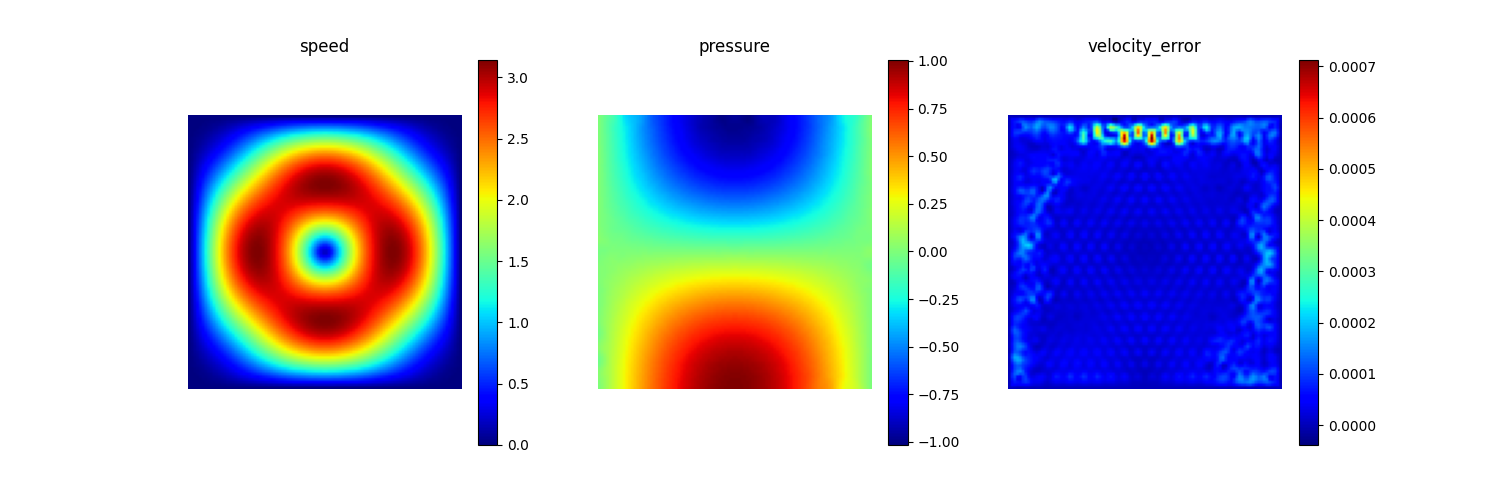

In [7]:
result = solve_stokes(h=0.05)

mesh, layout, fields = result["mesh"], result["layout"], result["fields"]
speed = torch.norm(fields["u"], dim=1)
pressure = layout.prolong("p", fields["p"])
velocity_error = torch.norm(fields["u"] - exact_velocity(mesh.points), dim=1)

mesh.plot(
    {"speed": speed, "pressure": pressure, "velocity_error": velocity_error},
    save_path="stokes_taylor_hood.png", show_mesh=False, cmap="jet",
)
plt.close("all")  # mesh.plot leaves its figure open; avoid a duplicate inline render
from IPython.display import Image
Image("stokes_taylor_hood.png")

## Convergence study

Taylor-Hood is second-order accurate: velocity $H^1$ and pressure $L^2$
errors should both fall as $O(h^2)$.

h          H1_vel         L2_pres        rate_u   rate_p  
0.1000     2.264616e-01   1.452436e-02   -        -       
0.0500     5.987253e-02   3.602646e-03   1.92     2.01    
0.0250     1.486821e-02   5.861047e-04   2.01     2.62    


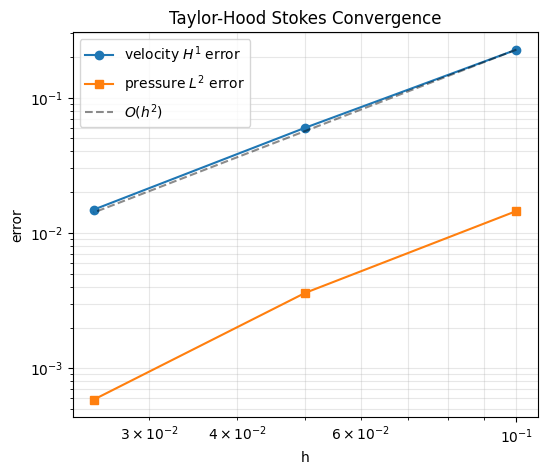

In [8]:
h_values = [0.1, 0.05, 0.025]
results = [solve_stokes(h=h, verbose=False) for h in h_values]

print("{:<10s} {:<14s} {:<14s} {:<8s} {:<8s}".format("h", "H1_vel", "L2_pres", "rate_u", "rate_p"))
for i, res in enumerate(results):
    if i == 0:
        rate_u, rate_p = "-", "-"
    else:
        prev = results[i - 1]
        rate_u = f"{math.log(prev['h1_u'] / res['h1_u']) / math.log(prev['h'] / res['h']):.2f}"
        rate_p = f"{math.log(prev['l2_p'] / res['l2_p']) / math.log(prev['h'] / res['h']):.2f}"
    print(f"{res['h']:<10.4f} {res['h1_u']:<14.6e} {res['l2_p']:<14.6e} {rate_u:<8s} {rate_p:<8s}")

hs = np.array([r["h"] for r in results])
h1_us = np.array([r["h1_u"] for r in results])
l2_ps = np.array([r["l2_p"] for r in results])

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(hs, h1_us, "o-", label=r"velocity $H^1$ error")
ax.loglog(hs, l2_ps, "s-", label=r"pressure $L^2$ error")
ax.loglog(hs, h1_us[0] * (hs / hs[0]) ** 2, "k--", alpha=0.45, label=r"$O(h^2)$")
ax.set_xlabel("h")
ax.set_ylabel("error")
ax.set_title("Taylor-Hood Stokes Convergence")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()